# Full-Study Data Preprocessing (Step by Step)

This notebook preprocesses raw data for the SPI/AI project using:
- ADM3 tehsil boundaries
- DEM
- 2024 land cover
- OSM roads (primary/secondary)

Snow/ice is intentionally excluded for now.

Before running cells, manually select the `sds` kernel.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Tuple
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio import features
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.warp import reproject
from scipy import ndimage
from shapely.geometry import box

In [2]:
# Paths and constants
project_root = Path('/home/wasif/sds/sds/spi_gb_north')
raw_dir = project_root / 'data' / 'raw'
interim_dir = project_root / 'data' / 'interim'
processed_dir = project_root / 'data' / 'processed'
metadata_dir = project_root / 'data' / 'metadata'

for d in [interim_dir, processed_dir, metadata_dir]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_CRS = 'EPSG:32643'
TARGET_RESOLUTION_M = 100.0

# Current landcover tiles are encoded as sequential WorldCover classes 1..11.
# Key classes used here: 1 = tree cover, 8 = permanent water bodies.
FOREST_CODE = 1
WATER_CODE = 8

# Tehsil lists used to define the true AOI boundary (Pakistan side only).
aoi_tehsils_file = Path('/home/wasif/sds/sds/project/aoi_tehsils_list.txt')
AJK_TEHSILS = [
    'BAGH', 'DHEERKOT', 'BARNALA', 'BHIMBER', 'SAMAHNI',
    'HATTIAN BALA', 'HAVELI', 'KOTLI', 'NAKIAL', 'SEHNSA',
    'DUDYAL', 'MIRPUR', 'MUZAFFARABAD', 'ATHUMQAM', 'ABBASPUR',
    'HAJEERA', 'RAWALAKOT', 'PALLANDARI'
 ]

admin_path = raw_dir / 'admin_boundaries' / 'geoBoundaries-PAK-ADM3.geojson'
dem_path = raw_dir / 'dem' / 'dem.tif'
roads_path = raw_dir / 'roads' / 'spi_gb_north.gpkg'
clipping_boundary_path = raw_dir / 'roads' / 'clipping_boundary.geojson'
landcover_files = sorted((raw_dir / 'landcover').glob('*.tif'))

print('Landcover files:', [p.name for p in landcover_files])
print('AOI list file exists:', aoi_tehsils_file.exists())

Landcover files: ['landcover1.tif', 'landcover2.tif', 'landcover3.tif']
AOI list file exists: True


In [3]:
@dataclass
class TemplateGrid:
    transform: rasterio.Affine
    width: int
    height: int
    crs: str
    resolution_m: float


def fix_geometries(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()
    gdf['geometry'] = gdf.geometry.make_valid()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def normalize_name(text: str) -> str:
    text = text.upper().strip()
    text = text.replace('`', '')
    text = re.sub(r'[^A-Z0-9]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def parse_tehsil_list_file(path: Path) -> set[str]:
    if not path.exists():
        return set()

    raw = path.read_text(encoding='utf-8')
    raw = raw.replace('\\n', '\n')
    names: set[str] = set()
    for line in raw.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.lower().startswith('names of'):
            continue
        names.add(normalize_name(line))
    return names


def zscore(series: pd.Series) -> pd.Series:
    std = series.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


def create_template_grid(boundary_utm: gpd.GeoDataFrame, resolution_m: float) -> TemplateGrid:
    minx, miny, maxx, maxy = boundary_utm.total_bounds
    width = int(np.ceil((maxx - minx) / resolution_m))
    height = int(np.ceil((maxy - miny) / resolution_m))
    transform = from_origin(minx, maxy, resolution_m, resolution_m)

    return TemplateGrid(
        transform=transform,
        width=width,
        height=height,
        crs=TARGET_CRS,
        resolution_m=resolution_m,
    )


def reproject_raster_to_template(
    src_path: Path,
    grid: TemplateGrid,
    resampling: Resampling,
    dst_nodata: float,
    band: int = 1,
) -> np.ndarray:
    with rasterio.open(src_path) as src:
        dst = np.full((grid.height, grid.width), dst_nodata, dtype=np.float32)
        reproject(
            source=rasterio.band(src, band),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=grid.transform,
            dst_crs=grid.crs,
            dst_nodata=dst_nodata,
            resampling=resampling,
        )
    return dst


def merge_landcover_tiles_to_template(landcover_paths: Iterable[Path], grid: TemplateGrid) -> np.ndarray:
    mosaic = np.zeros((grid.height, grid.width), dtype=np.uint8)
    for path in landcover_paths:
        tile = reproject_raster_to_template(
            src_path=path,
            grid=grid,
            resampling=Resampling.nearest,
            dst_nodata=0,
        )
        tile = tile.astype(np.uint8)
        # Fill mosaic wherever tile has valid class code (>0).
        mosaic = np.where(tile > 0, tile, mosaic).astype(np.uint8)
    return mosaic


def write_geotiff(out_path: Path, array: np.ndarray, grid: TemplateGrid, nodata: float, dtype: str) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(
        out_path,
        'w',
        driver='GTiff',
        width=grid.width,
        height=grid.height,
        count=1,
        dtype=dtype,
        crs=grid.crs,
        transform=grid.transform,
        nodata=nodata,
        compress='deflate',
    ) as dst:
        dst.write(array.astype(dtype), 1)


def compute_tri(dem: np.ndarray) -> np.ndarray:
    dem = dem.astype(np.float32)
    valid_center = np.isfinite(dem)

    acc = np.zeros_like(dem, dtype=np.float32)
    count = np.zeros_like(dem, dtype=np.float32)

    directions: Tuple[Tuple[int, int], ...] = (
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    )

    for dy, dx in directions:
        shifted = np.roll(np.roll(dem, dy, axis=0), dx, axis=1)
        valid = valid_center & np.isfinite(shifted)

        if dy == -1:
            valid[-1, :] = False
        if dy == 1:
            valid[0, :] = False
        if dx == -1:
            valid[:, -1] = False
        if dx == 1:
            valid[:, 0] = False

        diff2 = np.zeros_like(dem, dtype=np.float32)
        diff2[valid] = (shifted[valid] - dem[valid]) ** 2
        acc += diff2
        count += valid.astype(np.float32)

    tri = np.full_like(dem, np.nan, dtype=np.float32)
    ok = count > 0
    tri[ok] = np.sqrt(acc[ok] / count[ok])
    return tri


def linestring_primary_secondary_mask(value: object) -> bool:
    if value is None:
        return False
    text = str(value).lower()
    return ('primary' in text) or ('secondary' in text)


def build_tehsil_label_raster(tehsils: gpd.GeoDataFrame, grid: TemplateGrid) -> np.ndarray:
    shapes = ((geom, idx + 1) for idx, geom in enumerate(tehsils.geometry))
    labels = features.rasterize(
        shapes=shapes,
        out_shape=(grid.height, grid.width),
        transform=grid.transform,
        fill=0,
        dtype='int32',
        all_touched=False,
    )
    return labels


def zonal_mean_from_labels(
    values: np.ndarray,
    labels: np.ndarray,
    n_labels: int,
    valid_mask: np.ndarray | None = None,
) -> np.ndarray:
    mask = (labels > 0) & np.isfinite(values)
    if valid_mask is not None:
        mask &= valid_mask

    sums = np.bincount(labels[mask], weights=values[mask], minlength=n_labels + 1)
    counts = np.bincount(labels[mask], minlength=n_labels + 1)

    out = np.full(n_labels, np.nan, dtype=np.float64)
    nz = counts[1:] > 0
    out[nz] = sums[1:][nz] / counts[1:][nz]
    return out


def zonal_percent_class_from_labels(
    class_mask: np.ndarray,
    labels: np.ndarray,
    n_labels: int,
    denominator_mask: np.ndarray,
) -> np.ndarray:
    denom_counts = np.bincount(
        labels[(labels > 0) & denominator_mask],
        minlength=n_labels + 1,
    )
    class_counts = np.bincount(
        labels[(labels > 0) & denominator_mask & class_mask],
        minlength=n_labels + 1,
    )

    pct = np.full(n_labels, np.nan, dtype=np.float64)
    nz = denom_counts[1:] > 0
    pct[nz] = (class_counts[1:][nz] / denom_counts[1:][nz]) * 100.0
    return pct


def raster_extent(grid: TemplateGrid) -> tuple[float, float, float, float]:
    x_min = grid.transform.c
    x_max = x_min + (grid.width * grid.transform.a)
    y_max = grid.transform.f
    y_min = y_max + (grid.height * grid.transform.e)
    return (x_min, x_max, y_min, y_max)


def plot_raster(array: np.ndarray, grid: TemplateGrid, title: str, cmap: str = 'viridis', vmin=None, vmax=None) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    arr = np.array(array, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    im = ax.imshow(arr, extent=raster_extent(grid), origin='upper', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    plt.colorbar(im, ax=ax, shrink=0.75)
    plt.show()

## Step 1: Load and Prepare Boundaries

/tmp/ipykernel_30006/756665372.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geometry=[tehsils.unary_union],


Total ADM3 tehsils in Pakistan: 554
AOI tehsils selected: 81
Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/tehsils_north_kpk_gb_ajk_32643.gpkg
Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/aoi_boundary_north_kpk_gb_ajk_32643.gpkg


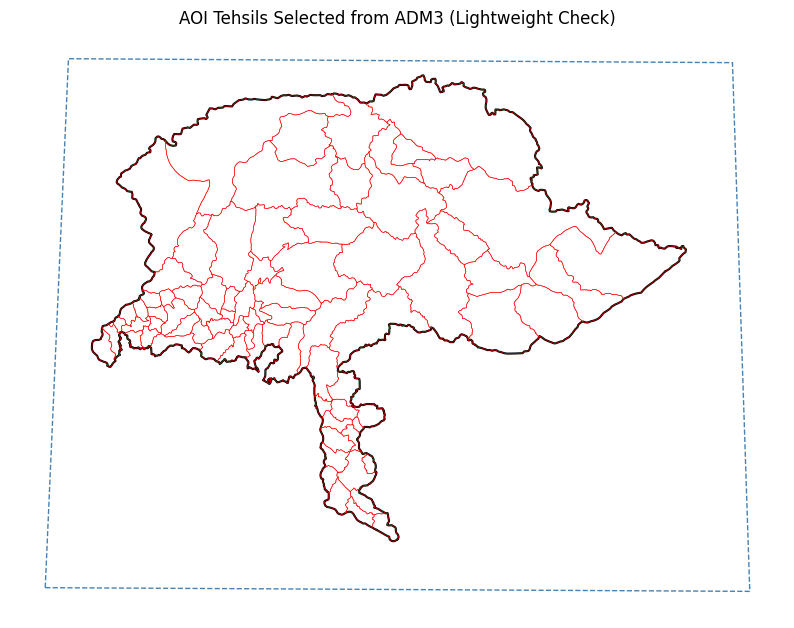

In [4]:
# Build AOI from ADM3 names and show a lightweight verification map.
manual_names = parse_tehsil_list_file(aoi_tehsils_file)
ajk_names = {normalize_name(x) for x in AJK_TEHSILS}
aoi_name_set = manual_names | ajk_names

all_tehsils = gpd.read_file(admin_path)
if all_tehsils.crs is None:
    all_tehsils = all_tehsils.set_crs('EPSG:4326')
all_tehsils = fix_geometries(all_tehsils)
all_tehsils['shapeName_norm'] = all_tehsils['shapeName'].map(normalize_name)

tehsils = all_tehsils[all_tehsils['shapeName_norm'].isin(aoi_name_set)].copy()

if len(tehsils) < 20:
    print('Warning: AOI list matching returned too few tehsils, using bbox intersection fallback.')
    bbox_boundary = gpd.read_file(clipping_boundary_path).to_crs('EPSG:4326')
    tehsils = all_tehsils[all_tehsils.intersects(bbox_boundary.geometry.unary_union)].copy()

tehsils = tehsils.to_crs(TARGET_CRS)
aoi_boundary_utm = gpd.GeoDataFrame(
    {'name': ['aoi_boundary']},
    geometry=[tehsils.unary_union],
    crs=TARGET_CRS,
)
aoi_boundary_wgs84 = aoi_boundary_utm.to_crs('EPSG:4326')

tehsils_out = interim_dir / 'tehsils_north_kpk_gb_ajk_32643.gpkg'
aoi_boundary_out = interim_dir / 'aoi_boundary_north_kpk_gb_ajk_32643.gpkg'
tehsils.to_file(tehsils_out, layer='tehsils_aoi', driver='GPKG')
aoi_boundary_utm.to_file(aoi_boundary_out, layer='aoi_boundary', driver='GPKG')

print('Total ADM3 tehsils in Pakistan:', len(all_tehsils))
print('AOI tehsils selected:', len(tehsils))
print('Saved:', tehsils_out)
print('Saved:', aoi_boundary_out)

# Lightweight verification map: bbox + AOI outline + selected tehsil outlines.
bbox_geom = gpd.GeoDataFrame(
    {'name': ['download_bbox']},
    geometry=[box(70.5850, 32.2600, 78.2900, 37.1700)],
    crs='EPSG:4326',
).to_crs(TARGET_CRS)

fig, ax = plt.subplots(1, 1, figsize=(10, 9))
bbox_geom.boundary.plot(ax=ax, color='steelblue', linewidth=1.0, linestyle='--')
aoi_boundary_utm.boundary.plot(ax=ax, color='black', linewidth=1.5)
tehsils.boundary.plot(ax=ax, color='red', linewidth=0.4)
ax.set_title('AOI Tehsils Selected from ADM3 (Lightweight Check)')
ax.set_axis_off()
plt.show()

## Step 2: Build the 100 m Analysis Grid

/tmp/ipykernel_30006/984783004.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [aoi_boundary_utm.geometry.unary_union],


Grid shape: (4801, 6122)
Resolution (m): 100.0


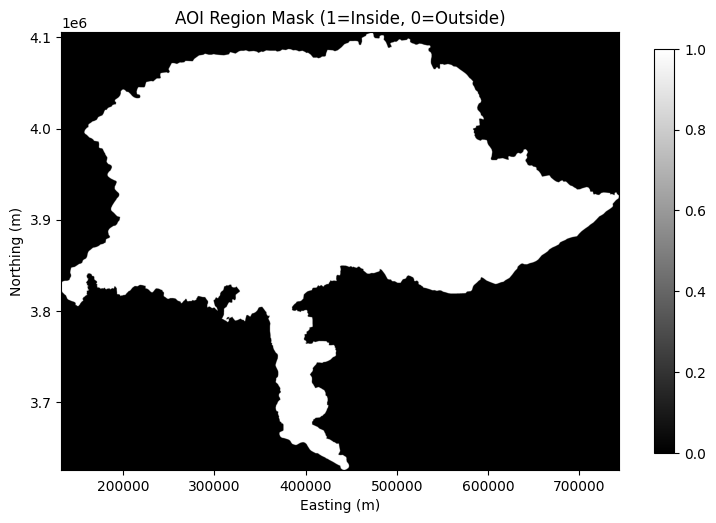

In [5]:
# Build analysis grid from AOI boundary (not the download bbox).
grid = create_template_grid(aoi_boundary_utm, TARGET_RESOLUTION_M)

region_mask = features.geometry_mask(
    [aoi_boundary_utm.geometry.unary_union],
    out_shape=(grid.height, grid.width),
    transform=grid.transform,
    invert=True,
)

print('Grid shape:', (grid.height, grid.width))
print('Resolution (m):', grid.resolution_m)

# Quick visualization of AOI raster mask.
plot_raster(region_mask.astype(float), grid, 'AOI Region Mask (1=Inside, 0=Outside)', cmap='gray')

## Step 3: Preprocess 2024 Land Cover

Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/worldcover_2024_merged_32643_100m_clip.tif
Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/forest_mask_2024_32643_100m.tif
Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/water_mask_2024_32643_100m.tif
Forest pixels: 67345
Water pixels: 2988690


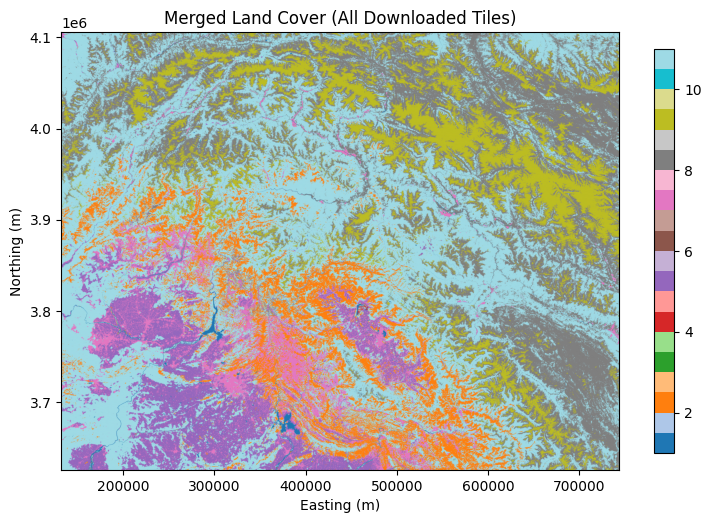

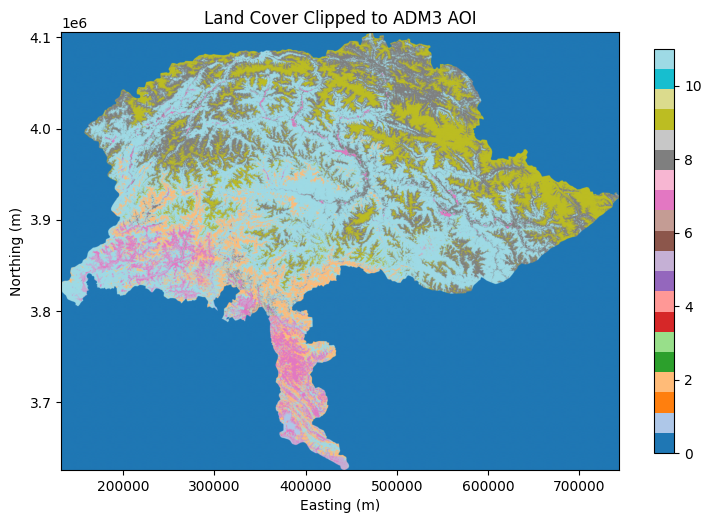

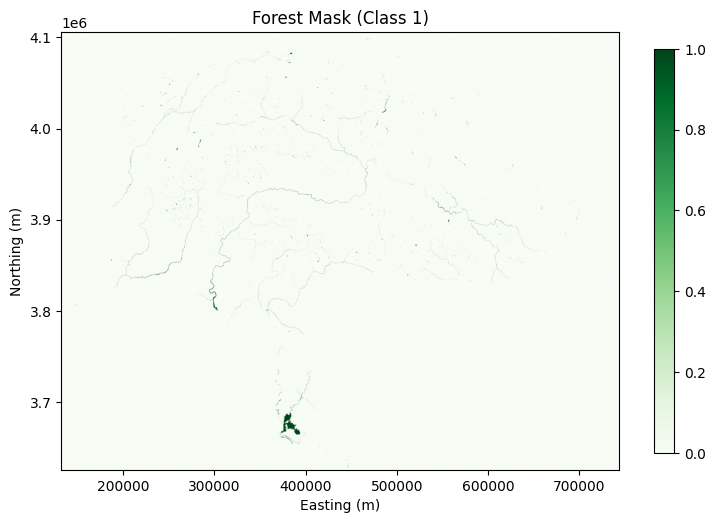

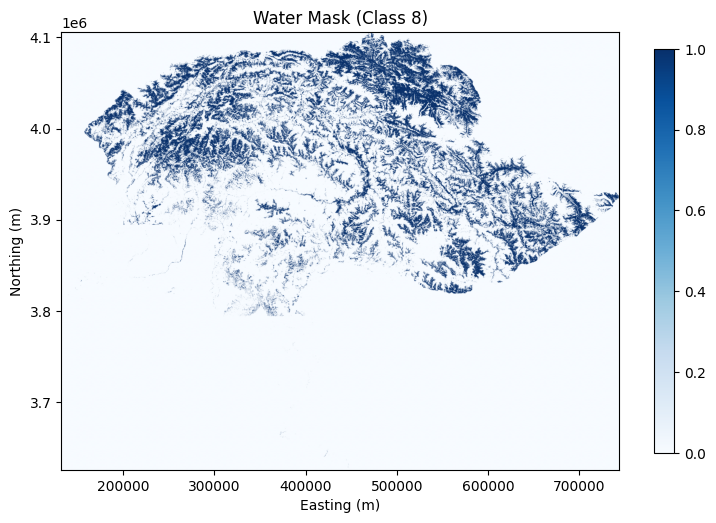

In [6]:
# Merge all 2024 land-cover tiles on the AOI analysis grid.
landcover_merged = merge_landcover_tiles_to_template(landcover_files, grid)
landcover = landcover_merged.copy()
landcover[~region_mask] = 0

lc_out = interim_dir / 'worldcover_2024_merged_32643_100m_clip.tif'
write_geotiff(lc_out, landcover, grid, nodata=0, dtype='uint8')

forest_mask = (landcover == FOREST_CODE).astype(np.uint8)
water_mask = (landcover == WATER_CODE).astype(np.uint8)

forest_out = interim_dir / 'forest_mask_2024_32643_100m.tif'
water_out = interim_dir / 'water_mask_2024_32643_100m.tif'
write_geotiff(forest_out, forest_mask, grid, nodata=0, dtype='uint8')
write_geotiff(water_out, water_mask, grid, nodata=0, dtype='uint8')

print('Saved:', lc_out)
print('Saved:', forest_out)
print('Saved:', water_out)

print('Forest pixels:', int(forest_mask.sum()))
print('Water pixels:', int(water_mask.sum()))

# Visualization
plot_raster(landcover_merged, grid, 'Merged Land Cover (All Downloaded Tiles)', cmap='tab20')
plot_raster(landcover, grid, 'Land Cover Clipped to ADM3 AOI', cmap='tab20')
plot_raster(forest_mask, grid, f'Forest Mask (Class {FOREST_CODE})', cmap='Greens', vmin=0, vmax=1)
plot_raster(water_mask, grid, f'Water Mask (Class {WATER_CODE})', cmap='Blues', vmin=0, vmax=1)

## Step 4: Preprocess DEM and Derive TRI

Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/dem_32643_100m_clip.tif
Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/tri_derived_32643_100m.tif


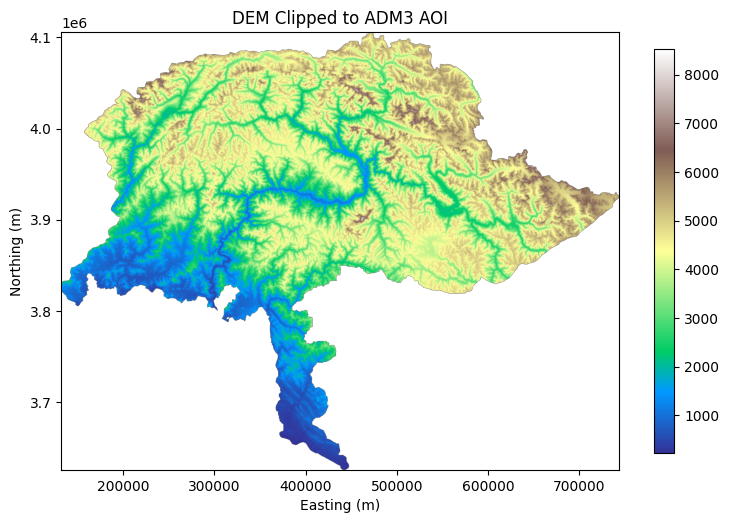

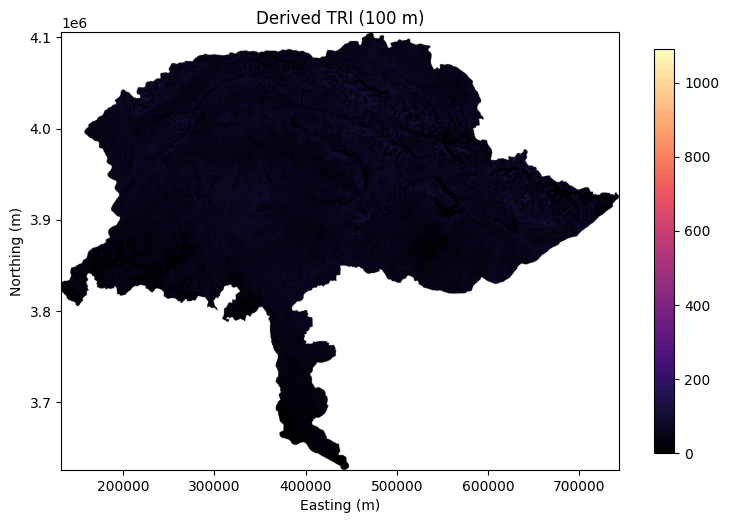

In [7]:
dem = reproject_raster_to_template(
    src_path=dem_path,
    grid=grid,
    resampling=Resampling.bilinear,
    dst_nodata=np.nan,
)
dem[~region_mask] = np.nan

tri = compute_tri(dem)
tri[~region_mask] = np.nan

dem_out = interim_dir / 'dem_32643_100m_clip.tif'
tri_out = interim_dir / 'tri_derived_32643_100m.tif'
write_geotiff(dem_out, dem, grid, nodata=np.nan, dtype='float32')
write_geotiff(tri_out, tri, grid, nodata=np.nan, dtype='float32')

print('Saved:', dem_out)
print('Saved:', tri_out)

# Visualization
plot_raster(dem, grid, 'DEM Clipped to ADM3 AOI', cmap='terrain')
plot_raster(tri, grid, 'Derived TRI (100 m)', cmap='magma')

## Step 5: Preprocess Roads and Distance-to-Roads

Raw roads features: 548115
Filtered roads features: 1749
Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/roads_primary_secondary_32643_clip.gpkg
Saved: /home/wasif/sds/sds/spi_gb_north/data/interim/distance_to_roads_32643_100m.tif


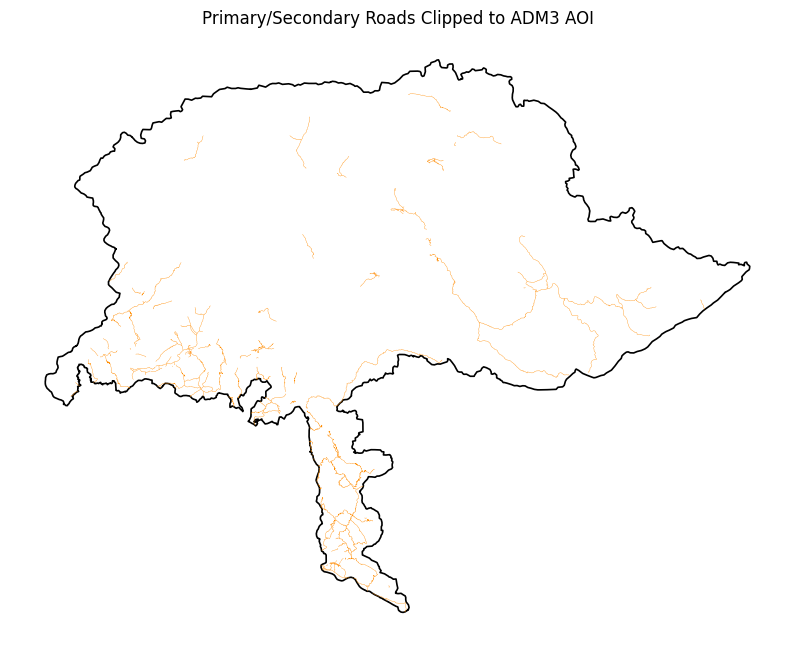

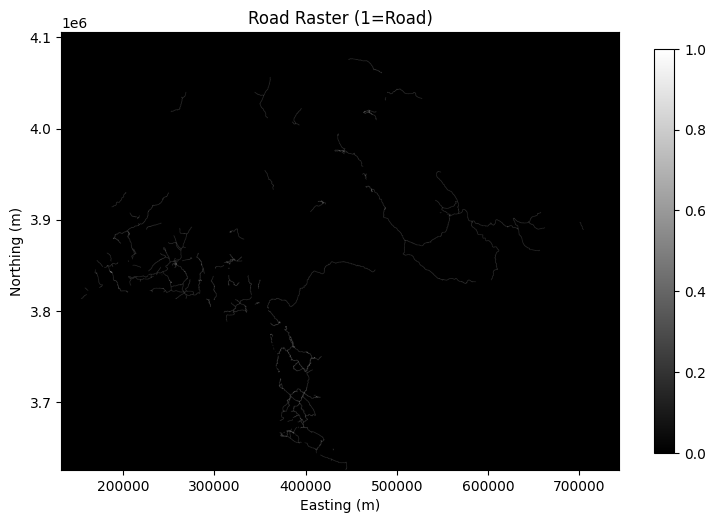

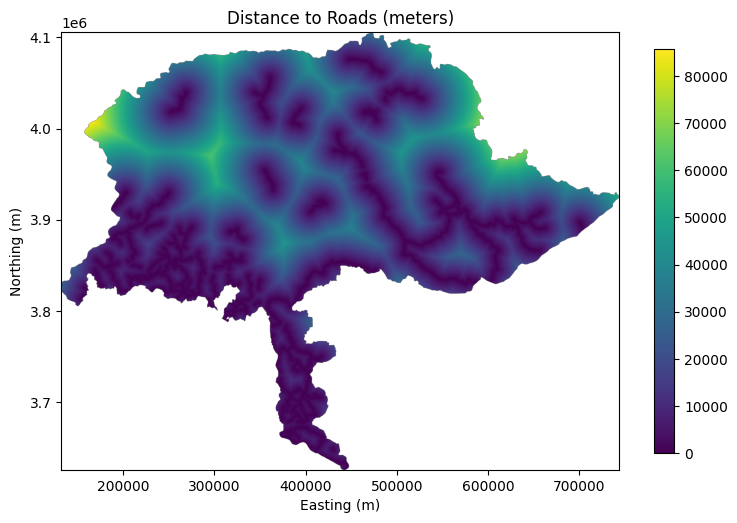

In [8]:
roads_raw = gpd.read_file(roads_path)
if roads_raw.crs is None:
    roads_raw = roads_raw.set_crs('EPSG:4326')

# Keep only line features, then keep primary/secondary highways.
roads = roads_raw[roads_raw.geometry.geom_type.isin(['LineString', 'MultiLineString'])].copy()
if 'highway' in roads.columns:
    roads = roads[roads['highway'].apply(linestring_primary_secondary_mask)].copy()

roads = roads.to_crs(TARGET_CRS)
roads = gpd.clip(roads, aoi_boundary_utm)

roads_out = interim_dir / 'roads_primary_secondary_32643_clip.gpkg'
roads.to_file(roads_out, layer='roads_primary_secondary', driver='GPKG')

road_raster = features.rasterize(
    ((geom, 1) for geom in roads.geometry),
    out_shape=(grid.height, grid.width),
    transform=grid.transform,
    fill=0,
    all_touched=True,
    dtype='uint8',
)
road_raster[~region_mask] = 0

dist_to_road = ndimage.distance_transform_edt(
    road_raster == 0,
    sampling=grid.resolution_m,
).astype(np.float32)
dist_to_road[~region_mask] = np.nan

dist_out = interim_dir / 'distance_to_roads_32643_100m.tif'
write_geotiff(dist_out, dist_to_road, grid, nodata=np.nan, dtype='float32')

print('Raw roads features:', len(roads_raw))
print('Filtered roads features:', len(roads))
print('Saved:', roads_out)
print('Saved:', dist_out)

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
aoi_boundary_utm.boundary.plot(ax=ax, color='black', linewidth=1.2)
roads.plot(ax=ax, color='darkorange', linewidth=0.25)
ax.set_title('Primary/Secondary Roads Clipped to ADM3 AOI')
ax.set_axis_off()
plt.show()

plot_raster(road_raster.astype(float), grid, 'Road Raster (1=Road)', cmap='gray', vmin=0, vmax=1)
plot_raster(dist_to_road, grid, 'Distance to Roads (meters)', cmap='viridis')

## Step 6: Compute Tehsil-Level Metrics

Tehsils with metrics: 81


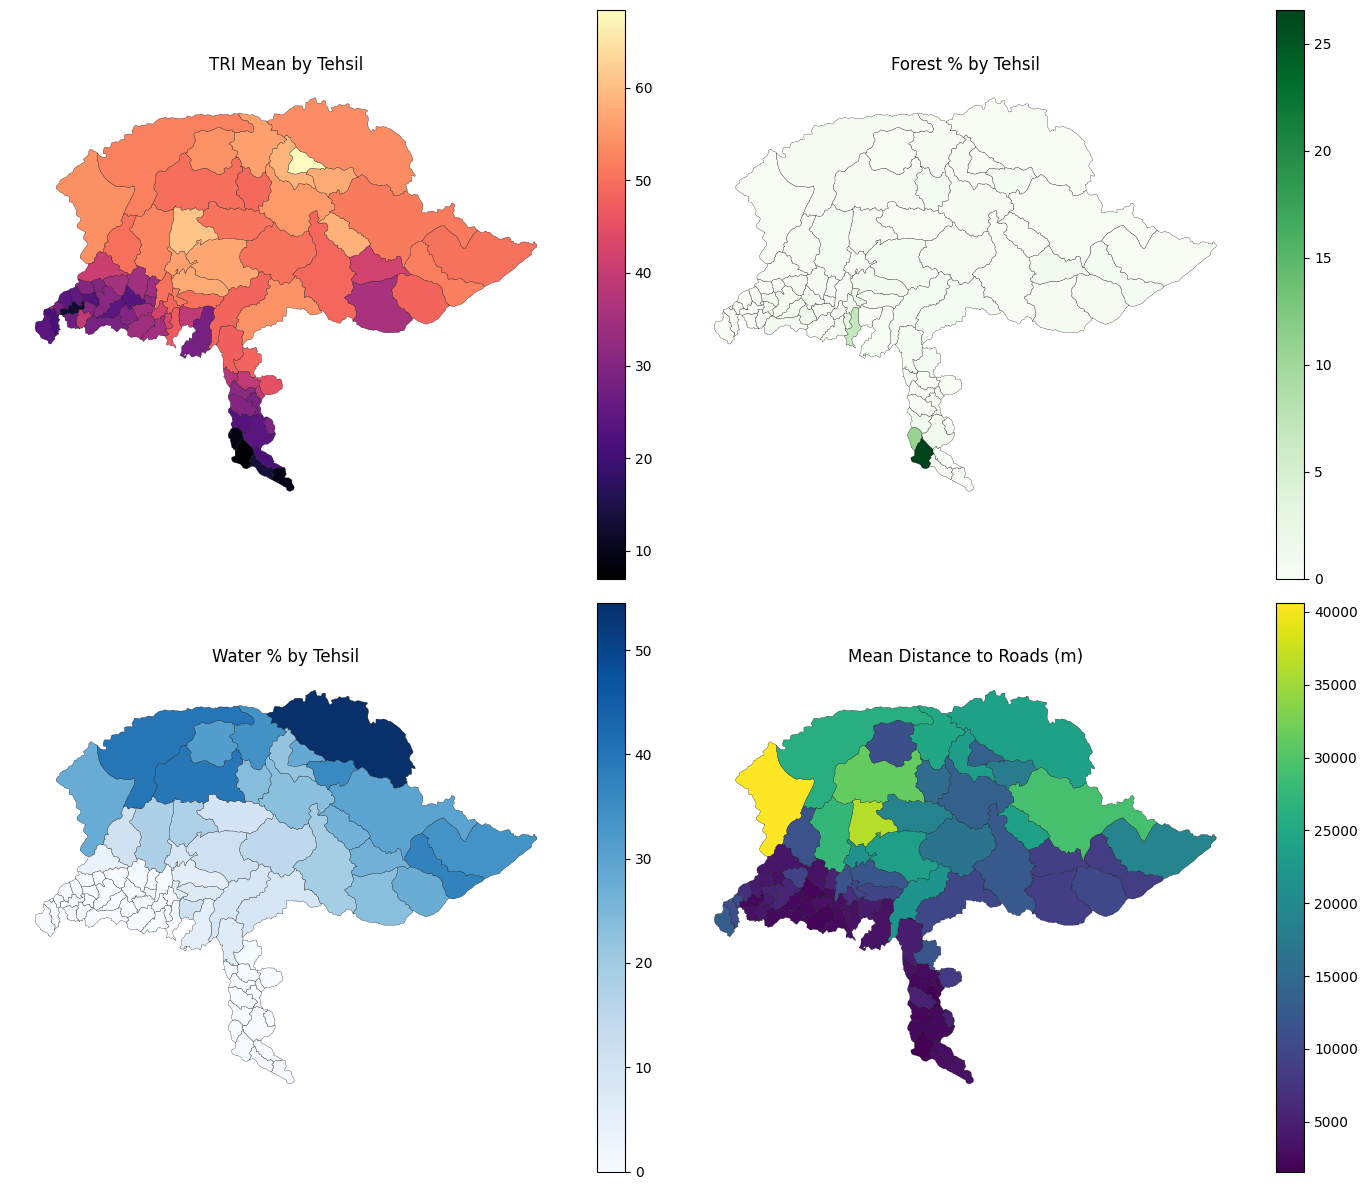

In [9]:
labels = build_tehsil_label_raster(tehsils, grid)
n_tehsils = len(tehsils)

lc_valid = (landcover > 0) & region_mask

tri_mean = zonal_mean_from_labels(tri, labels, n_tehsils)
dist_mean = zonal_mean_from_labels(dist_to_road, labels, n_tehsils)
forest_pct = zonal_percent_class_from_labels(forest_mask == 1, labels, n_tehsils, lc_valid)
water_pct = zonal_percent_class_from_labels(water_mask == 1, labels, n_tehsils, lc_valid)

tehsils_metrics = tehsils[['shapeName', 'shapeID', 'geometry']].copy()
tehsils_metrics['tehsil_area_km2'] = tehsils_metrics.geometry.area / 1_000_000.0

if roads.empty:
    tehsils_metrics['road_length_km'] = 0.0
else:
    intersection = gpd.overlay(
        roads[['geometry']],
        tehsils_metrics[['shapeID', 'geometry']],
        how='intersection',
    )
    if intersection.empty:
        road_len = pd.Series(dtype=float)
    else:
        intersection['seg_km'] = intersection.geometry.length / 1000.0
        road_len = intersection.groupby('shapeID')['seg_km'].sum()

    tehsils_metrics['road_length_km'] = tehsils_metrics['shapeID'].map(road_len).fillna(0.0)

tehsils_metrics['road_density_km_per_km2'] = tehsils_metrics['road_length_km'] / tehsils_metrics['tehsil_area_km2']
tehsils_metrics['tri_mean'] = tri_mean
tehsils_metrics['forest_pct'] = forest_pct
tehsils_metrics['water_pct'] = water_pct
tehsils_metrics['dist_to_roads_mean_m'] = dist_mean

print('Tehsils with metrics:', len(tehsils_metrics))
tehsils_metrics[['shapeName', 'tri_mean', 'forest_pct', 'water_pct', 'road_density_km_per_km2', 'dist_to_roads_mean_m']].head(10)

# Visualization: component maps
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
tehsils_metrics.plot(column='tri_mean', cmap='magma', legend=True, ax=axes[0, 0], edgecolor='black', linewidth=0.2)
axes[0, 0].set_title('TRI Mean by Tehsil')
axes[0, 0].set_axis_off()

tehsils_metrics.plot(column='forest_pct', cmap='Greens', legend=True, ax=axes[0, 1], edgecolor='black', linewidth=0.2)
axes[0, 1].set_title('Forest % by Tehsil')
axes[0, 1].set_axis_off()

tehsils_metrics.plot(column='water_pct', cmap='Blues', legend=True, ax=axes[1, 0], edgecolor='black', linewidth=0.2)
axes[1, 0].set_title('Water % by Tehsil')
axes[1, 0].set_axis_off()

tehsils_metrics.plot(column='dist_to_roads_mean_m', cmap='viridis', legend=True, ax=axes[1, 1], edgecolor='black', linewidth=0.2)
axes[1, 1].set_title('Mean Distance to Roads (m)')
axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

## Step 7: Build SPI (No Snow), AI, and Save Outputs

Saved: /home/wasif/sds/sds/spi_gb_north/data/processed/tehsil_spi_ai_fullstudy.geojson
Saved: /home/wasif/sds/sds/spi_gb_north/data/processed/tehsil_spi_ai_fullstudy.csv
Saved: /home/wasif/sds/sds/spi_gb_north/data/metadata/preprocessing_run_summary.txt


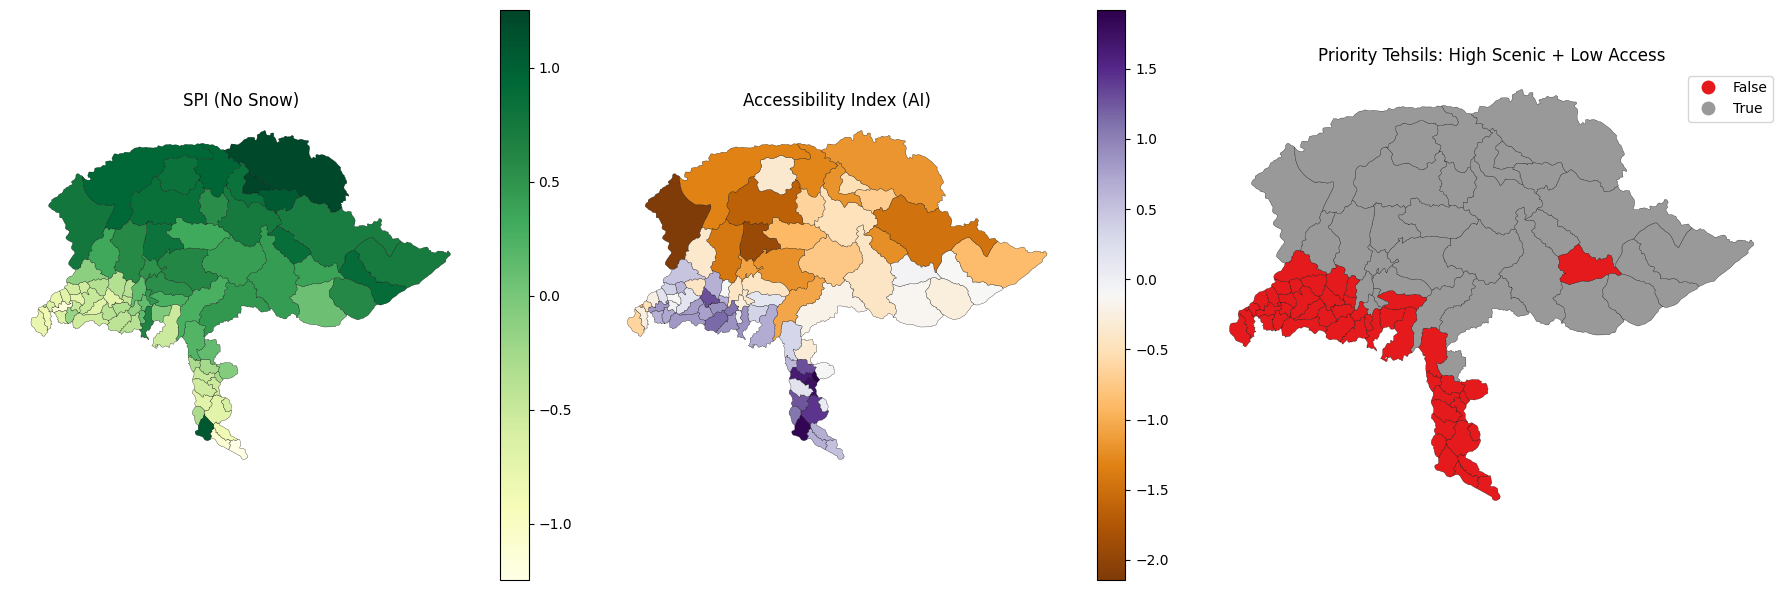

In [10]:
tri_z = zscore(tehsils_metrics['tri_mean'])
forest_z = zscore(tehsils_metrics['forest_pct'])
water_z = zscore(tehsils_metrics['water_pct'])

# Snow/ice deferred: normalize by active weight sum (0.85).
tehsils_metrics['spi_no_snow'] = ((0.4 * tri_z) + (0.25 * forest_z) + (0.2 * water_z)) / 0.85

road_density_z = zscore(tehsils_metrics['road_density_km_per_km2'])
dist_road_z = zscore(tehsils_metrics['dist_to_roads_mean_m'])
tehsils_metrics['ai'] = (0.5 * road_density_z) - (0.5 * dist_road_z)

spi_med = tehsils_metrics['spi_no_snow'].median()
ai_med = tehsils_metrics['ai'].median()
tehsils_metrics['priority_high_scenic_low_access'] = (
    (tehsils_metrics['spi_no_snow'] > spi_med)
    & (tehsils_metrics['ai'] < ai_med)
)

out_geojson = processed_dir / 'tehsil_spi_ai_fullstudy.geojson'
out_csv = processed_dir / 'tehsil_spi_ai_fullstudy.csv'
tehsils_metrics.to_file(out_geojson, driver='GeoJSON')
tehsils_metrics.drop(columns=['geometry']).to_csv(out_csv, index=False)

summary_path = metadata_dir / 'preprocessing_run_summary.txt'
summary_path.write_text(
    '\n'.join([
        f'tehsils_selected={len(tehsils_metrics)}',
        f'target_crs={TARGET_CRS}',
        f'target_resolution_m={grid.resolution_m}',
        f'landcover_tiles_merged={len(landcover_files)}',
        'snow_ice_status=deferred',
        f'outputs_geojson={out_geojson}',
        f'outputs_csv={out_csv}',
    ]) + '\n',
    encoding='utf-8',
)

print('Saved:', out_geojson)
print('Saved:', out_csv)
print('Saved:', summary_path)
tehsils_metrics[['shapeName', 'spi_no_snow', 'ai', 'priority_high_scenic_low_access']].head(10)

# Visualization: SPI, AI, and priority map
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
tehsils_metrics.plot(column='spi_no_snow', cmap='YlGn', legend=True, ax=axes[0], edgecolor='black', linewidth=0.2)
axes[0].set_title('SPI (No Snow)')
axes[0].set_axis_off()

tehsils_metrics.plot(column='ai', cmap='PuOr', legend=True, ax=axes[1], edgecolor='black', linewidth=0.2)
axes[1].set_title('Accessibility Index (AI)')
axes[1].set_axis_off()

tehsils_metrics.plot(
    column='priority_high_scenic_low_access',
    cmap='Set1',
    legend=True,
    ax=axes[2],
    edgecolor='black',
    linewidth=0.2,
 )
axes[2].set_title('Priority Tehsils: High Scenic + Low Access')
axes[2].set_axis_off()

plt.tight_layout()
plt.show()